In [1]:
import torch
from h5py import File as HDF5File

# Load dataset and device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


In [2]:
# from HEPGAN.preprocessing import DataMaker

# # Define variable and dataset
# batch_size = 128

# # Returns dataset plus kde and smote sampling datasets
# datasets    = DataMaker(jet_mass_data, batch_size = batch_size)

# torch.save({
#     "datasets": datasets
# }, "datasets.pt")

In [3]:
#### Run the cell above this once, then comment back out and use the cell below

from torch.utils.data import DataLoader
batch_size = 128

# Options
sampler = "smote"
sampler = "kde"

train_on = "signal"
train_on = "background"
train_on = "both"

saved = torch.load("datasets.pt")["datasets"]
dataset = saved[f"dataset_{train_on}"]
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

if sampler == "smote":
    sample_dataset = saved[f"smoteSampler_{train_on}"]
    sampleloader = DataLoader(sample_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
if sampler == "kde":
    sampleloader = saved[f"kdeSampler_{train_on}"]
    
print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

Number of samples: 8726
Image shape: torch.Size([8726, 16, 16])
Feature shape: torch.Size([8726, 9])


In [4]:
from HEPGAN.train import train
from HEPGAN.models import InitializeModel
from HEPGAN.loadSaveEval import eval_model, save, load

# Choose model and hyperparameters
model_type = "classical"
# model_type = "StronglyEntangling"
# model_type = "RandomLayer"

sigma = 0.1
n_epochs = 5
lr = .01

In [5]:
#### Initialize, train, and evaluate model
model = InitializeModel(model_type = model_type, sigma = sigma)

Device: cuda
Starting training on device: cuda
[Epoch 1/5] [Avg D loss: 0.1960] [Avg G loss: 110.5550]


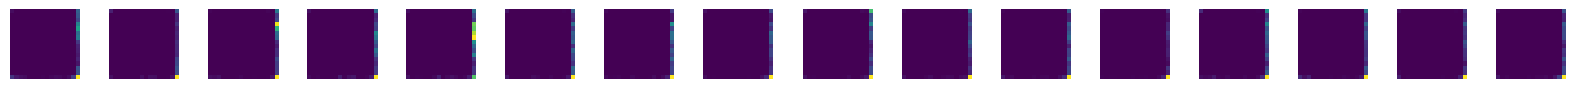


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 0.1781
Avg stat_loss       : 0.1563
  avg_dR_mean       : 0.0808
  avg_dR_std        : 0.0549
  avg_pix_mean      : 0.0132
  avg_pix_std       : 0.0073
Avg nnz_loss        : 1.1022

------- Final Batch (weighted into g_loss) -------
α = 0.02 ; β = 0.4 ; χ = 0.01
Last batch validity_loss: 0.0104
Last batch stat_loss:     0.0400
  dR_mean:   0.0640
  dR_std:    0.0228
  pix_mean:  0.0106
  pix_std:   0.0026
Last batch nnz_loss:      0.0055
Total g_loss = 1.1707

[Epoch 2/5] [Avg D loss: 0.1423] [Avg G loss: 1.1636]


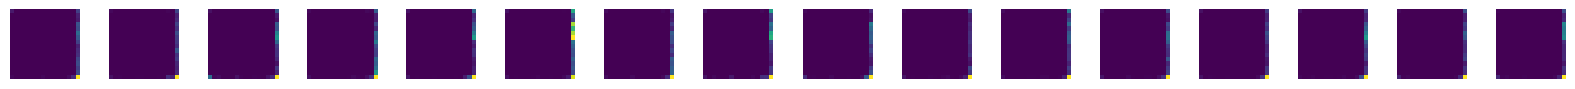


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 0.4910
Avg stat_loss       : 0.1207
  avg_dR_mean       : 0.0716
  avg_dR_std        : 0.0310
  avg_pix_mean      : 0.0142
  avg_pix_std       : 0.0040
Avg nnz_loss        : 0.0055

------- Final Batch (weighted into g_loss) -------
α = 0.02 ; β = 0.4 ; χ = 0.01
Last batch validity_loss: 0.0073
Last batch stat_loss:     0.0556
  dR_mean:   0.0770
  dR_std:    0.0384
  pix_mean:  0.0182
  pix_std:   0.0054
Last batch nnz_loss:      0.0057
Total g_loss = 1.0788

[Epoch 3/5] [Avg D loss: 0.1047] [Avg G loss: 1.2415]


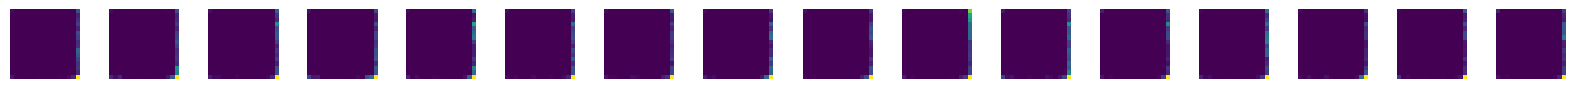


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 0.5327
Avg stat_loss       : 0.1639
  avg_dR_mean       : 0.0833
  avg_dR_std        : 0.0482
  avg_pix_mean      : 0.0246
  avg_pix_std       : 0.0078
Avg nnz_loss        : 0.0054

------- Final Batch (weighted into g_loss) -------
α = 0.02 ; β = 0.4 ; χ = 0.01
Last batch validity_loss: 0.0138
Last batch stat_loss:     0.0751
  dR_mean:   0.0881
  dR_std:    0.0578
  pix_mean:  0.0312
  pix_std:   0.0108
Last batch nnz_loss:      0.0050
Total g_loss = 1.3785

[Epoch 4/5] [Avg D loss: 0.0144] [Avg G loss: 1.6255]


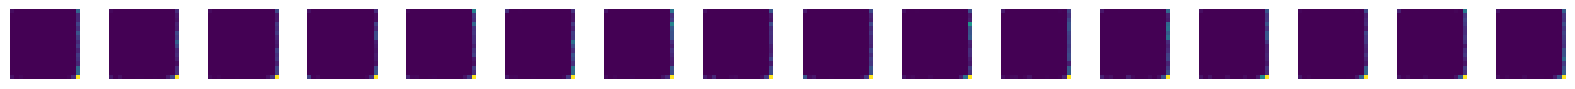


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 0.8762
Avg stat_loss       : 0.2094
  avg_dR_mean       : 0.0906
  avg_dR_std        : 0.0653
  avg_pix_mean      : 0.0390
  avg_pix_std       : 0.0145
Avg nnz_loss        : 0.0054

------- Final Batch (weighted into g_loss) -------
α = 0.02 ; β = 0.4 ; χ = 0.01
Last batch validity_loss: 0.0178
Last batch stat_loss:     0.0917
  dR_mean:   0.0917
  dR_std:    0.0717
  pix_mean:  0.0471
  pix_std:   0.0187
Last batch nnz_loss:      0.0056
Total g_loss = 1.6786

[Epoch 5/5] [Avg D loss: 0.0010] [Avg G loss: 1.8444]


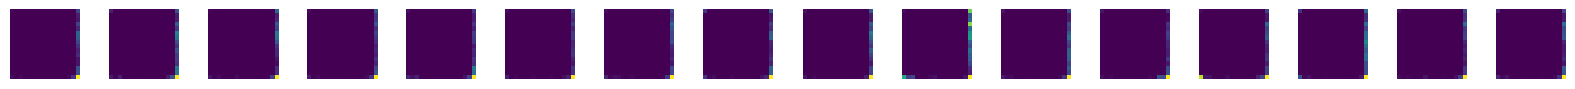


========== EPOCH STAT BREAKDOWN ==========
Avg validity_loss   : 1.0517
Avg stat_loss       : 0.2536
  avg_dR_mean       : 0.0951
  avg_dR_std        : 0.0780
  avg_pix_mean      : 0.0558
  avg_pix_std       : 0.0247
Avg nnz_loss        : 0.0054

------- Final Batch (weighted into g_loss) -------
α = 0.02 ; β = 0.4 ; χ = 0.01
Last batch validity_loss: 0.0206
Last batch stat_loss:     0.1103
  dR_mean:   0.0984
  dR_std:    0.0820
  pix_mean:  0.0647
  pix_std:   0.0307
Last batch nnz_loss:      0.0066
Total g_loss = 1.9699



In [6]:
train(model = model, dataloader = dataloader, sampleloader = sampleloader, n_epochs = n_epochs, lr = lr, batch_size = batch_size, debug = True)

Running KDE-based diagnostics...


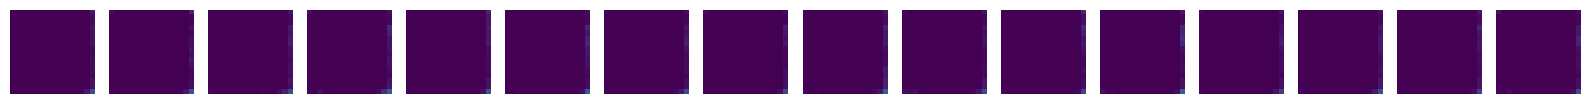

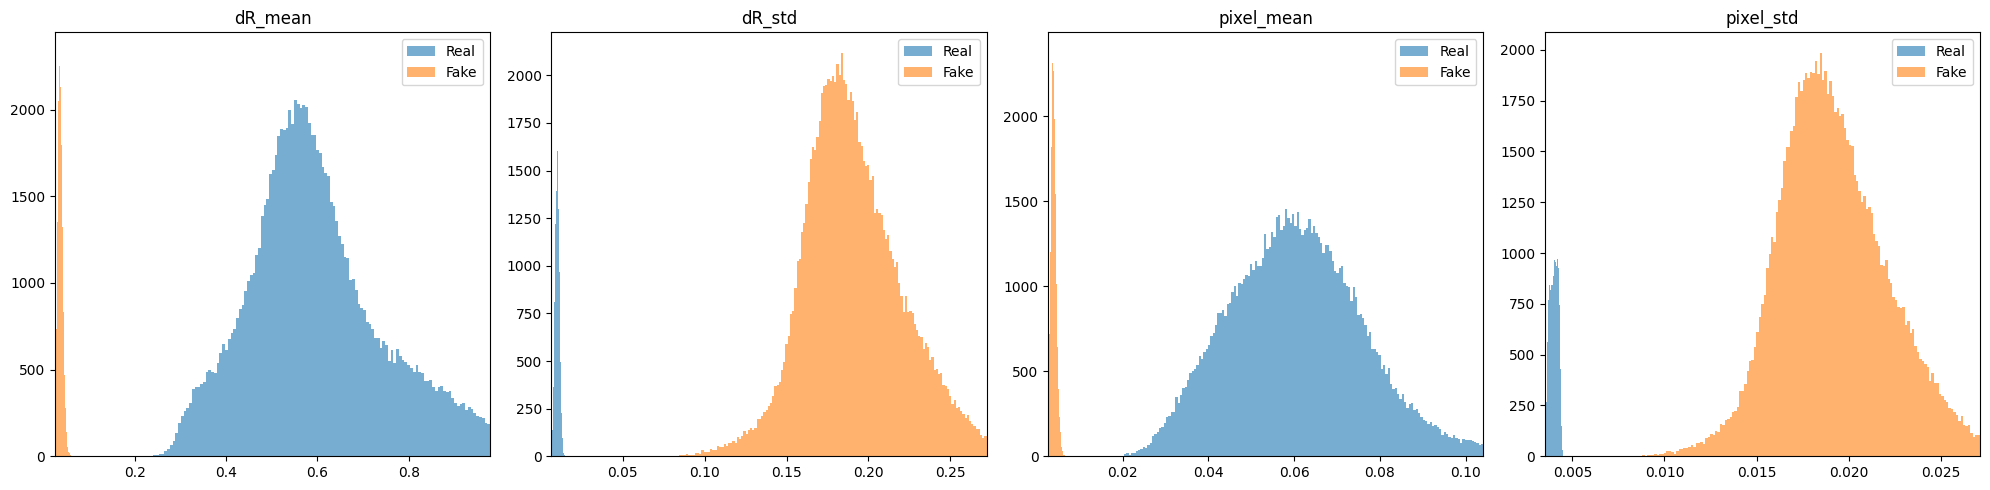

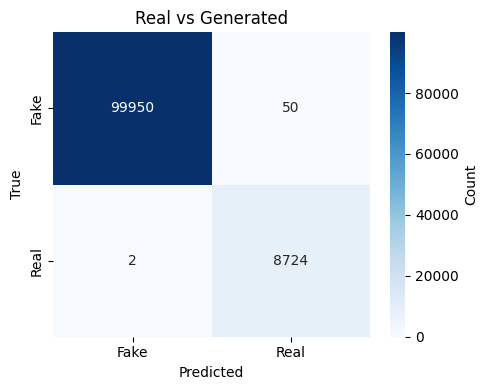

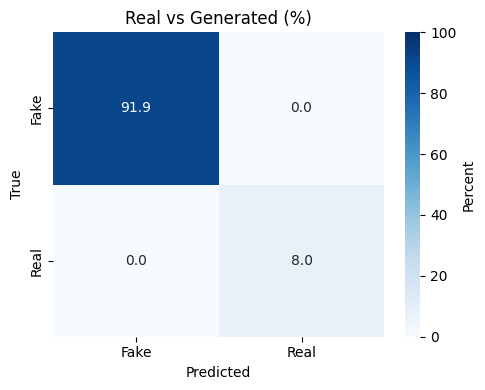

In [7]:
eval_model(model = model, dataset = dataset, sampleloader = sampleloader)

In [8]:
# Training automatically saves the best performing model parameters
# Optionally, save the final model parameters to a custom path
save(model = model, save_path = None)


Saved checkpoint to models/1202_1323.pt


In [ ]:
# Or load a previously trained model
load(model = model, load_path = "models/temp_gan_300.pt", device = device)

eval_model(model = model, dataset = dataset, sampleloader = sampleloader)

training a compatible model over in ICLR_backup. Need to port that over here to check if it's my training or eval that's messed up here